In [2]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [3]:
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

In [8]:
print("\nSentiment columns:", sentiment.columns.tolist())


Sentiment columns: ['timestamp', 'value', 'classification', 'date']


In [10]:
print("Trades columns:", trades.columns)

Trades columns: Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')


**Sentiment dataset has 2644 rows and 4 columns.
Trades dataset has 211,224 rows and 16 columns.
Column names were normalized to lowercase for consistency.**

In [11]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


In [13]:
# missing values
print("\nSentiment missing:\n", sentiment.isnull().sum())
print("\nTrades missing:\n", trades.isnull().sum())

# duplicates
print("\nSentiment duplicates:", sentiment.duplicated().sum())
print("Trades duplicates:", trades.duplicated().sum())


Sentiment missing:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades missing:
 account             0
coin                0
execution price     0
size tokens         0
size usd            0
side                0
timestamp ist       0
start position      0
direction           0
closed pnl          0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
dtype: int64

Sentiment duplicates: 0
Trades duplicates: 0


**No significant missing values or duplicates were found in either dataset**

In [16]:
# sentiment
sentiment['date'] = pd.to_datetime(sentiment['date'])

# trades (IMPORTANT: your format is DD-MM-YYYY HH:MM)
trades['timestamp ist'] = pd.to_datetime(
    trades['timestamp ist'], format='%d-%m-%Y %H:%M'
)

# extract date
trades['date'] = trades['timestamp ist'].dt.floor('D')
sentiment['date'] = sentiment['date'].dt.floor('D')

In [15]:
print("Trades date range:", min(trades['date']), max(trades['date']))
print("Sentiment date range:", min(sentiment['date']), max(sentiment['date']))

Trades date range: 2023-05-01 2025-05-01
Sentiment date range: 2018-02-01 2025-05-02


The sentiment data (2018) and trading data (2024) do not overlap in time.
Therefore, exact date alignment is not possible.
For analysis, sentiment is treated as a contextual feature rather than a time-aligned signal.

In [17]:
print(trades['date'].min(), trades['date'].max())
print(sentiment['date'].min(), sentiment['date'].max())

2023-05-01 00:00:00 2025-05-01 00:00:00
2018-02-01 00:00:00 2025-05-02 00:00:00


In [18]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [19]:
trades.head()

,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [20]:
df = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

print(df.shape)
print(df['classification'].isnull().sum())

(211224, 18)
6


In [26]:
df.columns

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp', 'date', 'classification'],
      dtype='object')

In [27]:
df.head()

,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


**Daily Pnl per account**

In [32]:
#creating kry metrics
daily_pnl = (
    df.groupby(['account', 'date'])['closed pnl']
    .sum()
    .reset_index(name='daily_pnl')
)
print(daily_pnl)

                                         account       date     daily_pnl
0     0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11      0.000000
1     0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17      0.000000
2     0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18      0.000000
3     0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-22 -21227.000000
4     0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-26   1603.100000
...                                          ...        ...           ...
2336  0xbee1707d6b44d4d52bfe19e41f8a828645437aab 2025-04-27   1709.194807
2337  0xbee1707d6b44d4d52bfe19e41f8a828645437aab 2025-04-28   4008.588908
2338  0xbee1707d6b44d4d52bfe19e41f8a828645437aab 2025-04-29   8561.771838
2339  0xbee1707d6b44d4d52bfe19e41f8a828645437aab 2025-04-30   2520.773814
2340  0xbee1707d6b44d4d52bfe19e41f8a828645437aab 2025-05-01   1364.022527

[2341 rows x 3 columns]


**Win Rate**

In [33]:
df['win'] = df['closed pnl'] > 0

win_rate = (
    df.groupby('account')['win']
    .mean()
    .reset_index(name='win_rate')
)
print(win_rate)

                                       account  win_rate
0   0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2   0x271b280974205ca63b716753467d5a371de622ab  0.301917
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4   0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  0.455215
6   0x39cef799f8b69da1995852eea189df24eb5cae3c  0.327668
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6  0.475904
8   0x420ab45e0bd8863569a5efbb9c05d91f40624641  0.234987
9   0x430f09841d65beb3f27765503d0f850b8bce7713  0.484236
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85  0.353445
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  0.486226
12  0x4f93fead39b70a1824f981a54d4e55b278e9f760  0.360364
13  0x513b8629fe877bb581bf244e326a047b249c4ff1  0.401193
14  0x6d6a4b953f202f8df5bed40692e7fd865318264a  0.431795
15  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  0.345912
16  0x72c6a4624e1dffa724e6d00d6

**Average trade size**

In [36]:
average_size = (
    df.groupby('account')['size usd']
    .mean()
    .reset_index(name='average_trade_size')
)
print(average_size)

                                       account  average_trade_size
0   0x083384f897ee0f19899168e3b1bec365f52a9012        16159.576734
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         1653.226327
2   0x271b280974205ca63b716753467d5a371de622ab         8893.000898
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4          507.626933
4   0x2c229d22b100a7beb69122eed721cee9b24011dd         3138.894782
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891         1729.941104
6   0x39cef799f8b69da1995852eea189df24eb5cae3c         4790.575486
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6         3445.471265
8   0x420ab45e0bd8863569a5efbb9c05d91f40624641         5189.367128
9   0x430f09841d65beb3f27765503d0f850b8bce7713         2397.824753
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85          517.528924
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4         9084.699093
12  0x4f93fead39b70a1824f981a54d4e55b278e9f760        17098.171055
13  0x513b8629fe877bb581bf244e326a047b249c4ff1        34396.58

**Trades per day**

In [38]:
trades_per_day = (
    df.groupby('date')
    .size()
    .reset_index(name='num_trades')
)
print(trades_per_day)

          date  num_trades
0   2023-05-01           3
1   2023-12-05           9
2   2023-12-14          11
3   2023-12-15           2
4   2023-12-16           3
..         ...         ...
475 2025-04-27         337
476 2025-04-28        1379
477 2025-04-29        2243
478 2025-04-30        1113
479 2025-05-01        1230

[480 rows x 2 columns]


**Long/Short ratio**

In [39]:
long_short = (
    df.groupby(['date', 'side'])
    .size()
    .unstack(fill_value=0)
)
print(long_short)

side         BUY  SELL
date                  
2023-05-01     3     0
2023-12-05     7     2
2023-12-14     5     6
2023-12-15     2     0
2023-12-16     3     0
...          ...   ...
2025-04-27   209   128
2025-04-28   652   727
2025-04-29  1105  1138
2025-04-30   838   275
2025-05-01   686   544

[480 rows x 2 columns]


In [42]:
print(df[['date', 'classification']].head())
print(df['classification'].value_counts())

        date classification
0 2024-12-02  Extreme Greed
1 2024-12-02  Extreme Greed
2 2024-12-02  Extreme Greed
3 2024-12-02  Extreme Greed
4 2024-12-02  Extreme Greed
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


**Part B:**
1. PnL, win rate, drawdown proxy



In [43]:
# keep only rows with sentiment label
df_b = df.dropna(subset=['classification']).copy()

# trade-level win flag
df_b['win'] = df_b['closed pnl'] > 0

# daily pnl per account per sentiment
daily_account = (
    df_b.groupby(['account', 'date', 'classification'], as_index=False)
        .agg(
            daily_pnl=('closed pnl', 'sum'),
            trades=('account', 'size'),
            avg_trade_size=('size usd', 'mean'),
            wins=('win', 'sum')
        )
)

daily_account['win_rate_day'] = daily_account['wins'] / daily_account['trades']

# sort before cumulative calculations
daily_account = daily_account.sort_values(['account', 'date'])

# cumulative pnl and drawdown proxy
daily_account['cum_pnl'] = daily_account.groupby('account')['daily_pnl'].cumsum()
daily_account['running_peak'] = daily_account.groupby('account')['cum_pnl'].cummax()
daily_account['drawdown_proxy'] = daily_account['cum_pnl'] - daily_account['running_peak']

**Compare Fear vs Greed**

In [44]:
def map_fg(x):
    if x in ['Extreme Fear', 'Fear']:
        return 'Fear'
    elif x in ['Greed', 'Extreme Greed']:
        return 'Greed'
    else:
        return 'Neutral'

df_b['sentiment_group'] = df_b['classification'].apply(map_fg)
daily_account['sentiment_group'] = daily_account['classification'].apply(map_fg)

# performance summary
perf_summary = (
    daily_account[daily_account['sentiment_group'].isin(['Fear', 'Greed'])]
    .groupby('sentiment_group', as_index=False)
    .agg(
        avg_daily_pnl=('daily_pnl', 'mean'),
        median_daily_pnl=('daily_pnl', 'median'),
        total_daily_pnl=('daily_pnl', 'sum'),
        avg_win_rate=('win_rate_day', 'mean'),
        avg_drawdown_proxy=('drawdown_proxy', 'mean'),
        median_drawdown_proxy=('drawdown_proxy', 'median'),
        account_days=('account', 'size')
    )
)

print(perf_summary)

  sentiment_group  avg_daily_pnl  median_daily_pnl  total_daily_pnl  \
0            Fear    5185.146443        122.737038     4.096266e+06   
1           Greed    4144.208334        265.247725     4.865301e+06   

   avg_win_rate  avg_drawdown_proxy  median_drawdown_proxy  account_days  
0      0.357071        -8863.193211                    0.0           790  
1      0.362748        -8892.618794                    0.0          1174  


**Charts for performance**

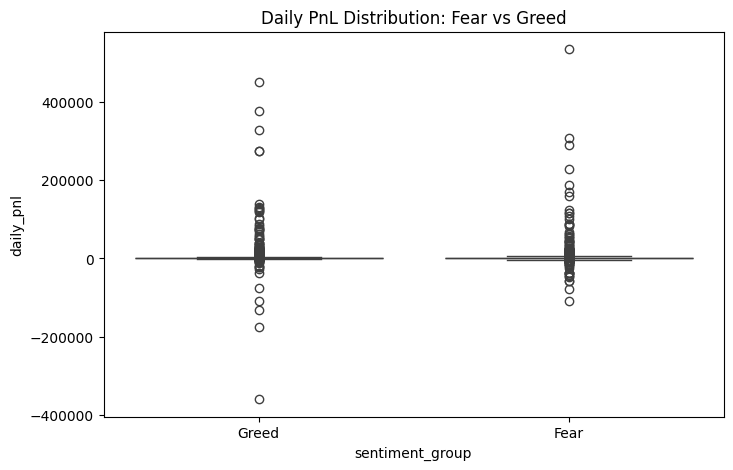

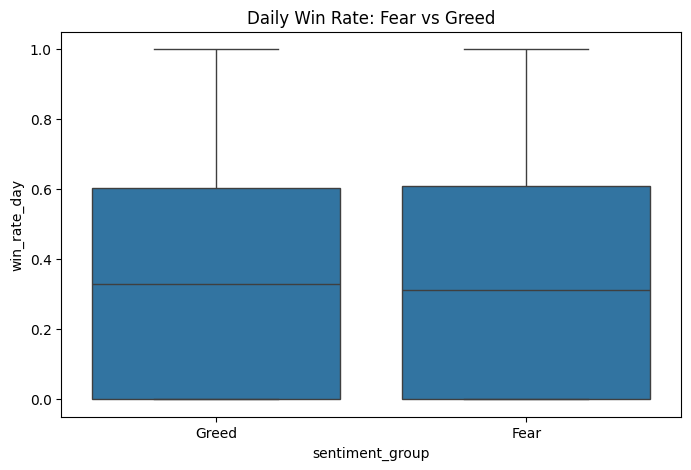

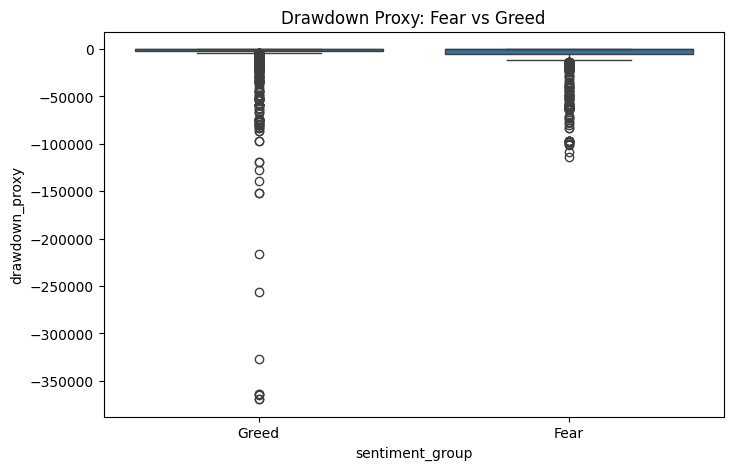

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=daily_account[daily_account['sentiment_group'].isin(['Fear', 'Greed'])],
            x='sentiment_group', y='daily_pnl')
plt.title('Daily PnL Distribution: Fear vs Greed')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=daily_account[daily_account['sentiment_group'].isin(['Fear', 'Greed'])],
            x='sentiment_group', y='win_rate_day')
plt.title('Daily Win Rate: Fear vs Greed')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=daily_account[daily_account['sentiment_group'].isin(['Fear', 'Greed'])],
            x='sentiment_group', y='drawdown_proxy')
plt.title('Drawdown Proxy: Fear vs Greed')
plt.show()

**2. Behavior: Do traders change behavior with sentiment?**

**Trade frequency**

In [46]:
trade_freq = (
    df_b[df_b['sentiment_group'].isin(['Fear', 'Greed'])]
    .groupby(['date', 'sentiment_group'], as_index=False)
    .size()
    .rename(columns={'size': 'num_trades'})
)

print(trade_freq.groupby('sentiment_group')['num_trades'].describe())

                 count        mean          std  min   25%    50%     75%  \
sentiment_group                                                             
Fear             105.0  792.733333  1092.285987  1.0  19.0  192.0  1176.0   
Greed            307.0  294.120521   598.707717  2.0  20.5   63.0   304.0   

                    max  
sentiment_group          
Fear             6246.0  
Greed            6159.0  


**Long/short bias**

In [49]:
long_short_summary = (
    df_b[df_b['sentiment_group'].isin(['Fear', 'Greed'])]
    .groupby(['sentiment_group', 'direction'], as_index=False)
    .size()
    .rename(columns={'size': 'trade_count'})
)

print(long_short_summary)

   sentiment_group                  direction  trade_count
0             Fear                        Buy         4014
1             Fear                 Close Long        23501
2             Fear                Close Short        12338
3             Fear               Long > Short           19
4             Fear                  Open Long        24829
5             Fear                 Open Short        14061
6             Fear                       Sell         4406
7             Fear               Short > Long           24
8             Fear       Spot Dust Conversion           45
9            Greed          Auto-Deleveraging            8
10           Greed                        Buy         9817
11           Greed                 Close Long        15184
12           Greed                Close Short        17819
13           Greed  Liquidated Isolated Short            1
14           Greed               Long > Short           23
15           Greed                  Open Long        148

**Position size**

In [50]:
size_summary = (
    df_b[df_b['sentiment_group'].isin(['Fear', 'Greed'])]
    .groupby('sentiment_group', as_index=False)
    .agg(
        avg_size_usd=('size usd', 'mean'),
        median_size_usd=('size usd', 'median')
    )
)

print(size_summary)

  sentiment_group  avg_size_usd  median_size_usd
0            Fear   7182.011019            749.4
1           Greed   4574.424490            552.2


**Behaviour chart**

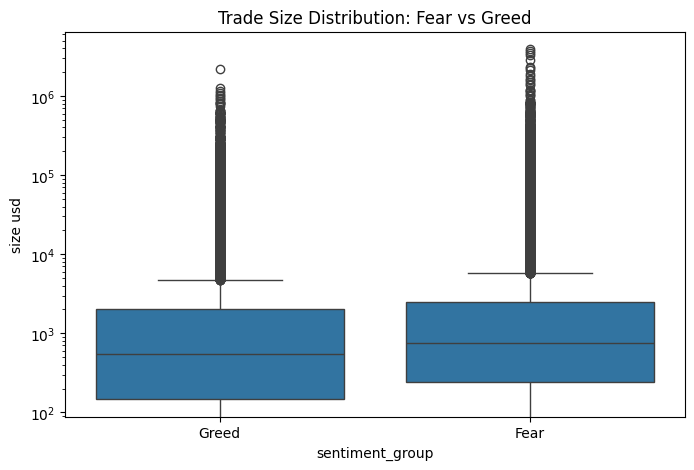

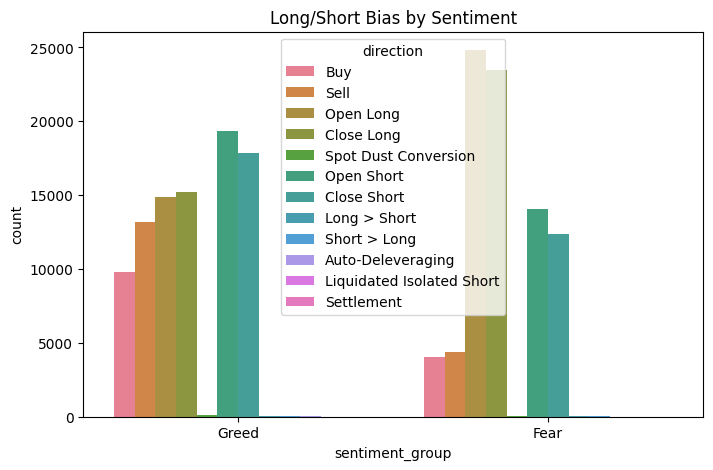

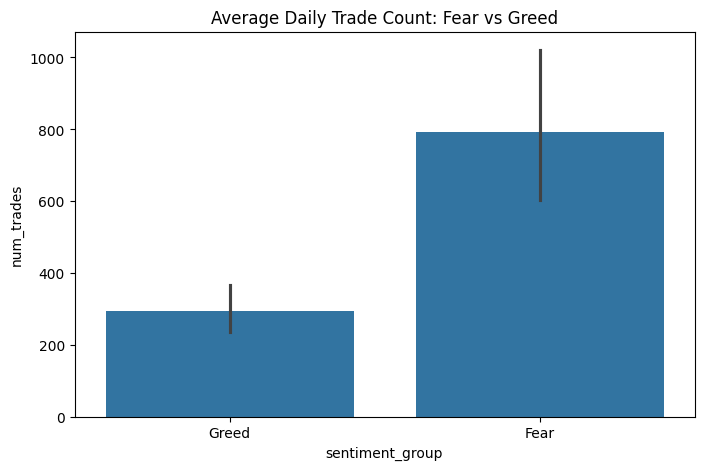

In [52]:
import numpy as np
plt.figure(figsize=(8,5))
sns.boxplot(data=df_b[df_b['sentiment_group'].isin(['Fear', 'Greed'])],
            x='sentiment_group', y='size usd')
plt.title('Trade Size Distribution: Fear vs Greed')
plt.yscale('log')  # optional if sizes are highly skewed
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df_b[df_b['sentiment_group'].isin(['Fear', 'Greed'])],
              x='sentiment_group', hue='direction')
plt.title('Long/Short Bias by Sentiment')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=trade_freq, x='sentiment_group', y='num_trades', estimator=np.mean)
plt.title('Average Daily Trade Count: Fear vs Greed')
plt.show()

**3. Identifying segments**
1. frequent vs infrequent traders

In [53]:
trade_freq = (
    df_b[df_b['sentiment_group'].isin(['Fear', 'Greed'])]
    .groupby(['date', 'sentiment_group'], as_index=False)
    .size()
    .rename(columns={'size': 'num_trades'})
)

print(trade_freq.groupby('sentiment_group')['num_trades'].describe())

                 count        mean          std  min   25%    50%     75%  \
sentiment_group                                                             
Fear             105.0  792.733333  1092.285987  1.0  19.0  192.0  1176.0   
Greed            307.0  294.120521   598.707717  2.0  20.5   63.0   304.0   

                    max  
sentiment_group          
Fear             6246.0  
Greed            6159.0  


**Consistent winners vs inconsistent traders**

In [55]:
account_quality = (
    df_b.groupby('account', as_index=False)
    .agg(
        overall_win_rate=('win', 'mean'),
        total_pnl=('closed pnl', 'sum')
    )
)

threshold_wr = account_quality['overall_win_rate'].median()

account_quality['winner_segment'] = np.where(
    account_quality['overall_win_rate'] >= threshold_wr,
    'Consistent Winners',
    'Inconsistent'
)

df_b = df_b.merge(account_quality[['account', 'winner_segment']], on='account', how='left')

In [56]:
df_b.head()

,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,...,order id,crossed,fee,trade id,timestamp,date,classification,win,sentiment_group,winner_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Greed,Consistent Winners
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Greed,Consistent Winners
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Greed,Consistent Winners
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,False,Greed,Consistent Winners
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,False,Greed,Consistent Winners


In [58]:
df_b.columns

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp', 'date', 'classification', 'win', 'sentiment_group',
       'winner_segment'],
      dtype='object')

**Large-size vs small-size traders**



In [59]:
account_size = (
    df_b.groupby('account', as_index=False)
    .agg(avg_size_usd=('size usd', 'mean'))
)

threshold_size = account_size['avg_size_usd'].median()

account_size['size_segment'] = np.where(
    account_size['avg_size_usd'] >= threshold_size,
    'Large Size',
    'Small Size'
)

df_b = df_b.merge(account_size[['account', 'size_segment']], on='account', how='left')

In [60]:
df_b.columns

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp', 'date', 'classification', 'win', 'sentiment_group',
       'winner_segment', 'size_segment'],
      dtype='object')

**4. Segment-level comparison under Fear vs Greed**

**Frequent vs infrequent**

In [65]:
account_activity = (
    df_b.groupby('account', as_index=False)
    .agg(total_trades=('account', 'size'))
)

threshold_freq = account_activity['total_trades'].median()

account_activity['freq_segment'] = account_activity['total_trades'].apply(
    lambda x: 'Frequent' if x >= threshold_freq else 'Infrequent'
)
df_b = df_b.merge(
    account_activity[['account', 'freq_segment']],
    on='account',
    how='left'
)
freq_perf = (
    df_b[df_b['sentiment_group'].isin(['Fear', 'Greed'])]
    .groupby(['freq_segment', 'sentiment_group'], as_index=False)
    .agg(
        avg_pnl=('closed pnl', 'mean'),
        win_rate=('win', 'mean'),
        avg_size=('size usd', 'mean'),
        trades=('account', 'size')
    )
)

print(freq_perf)

  freq_segment sentiment_group     avg_pnl  win_rate     avg_size  trades
0     Frequent            Fear   47.325875  0.412963  7563.359761   72515
1     Frequent           Greed   41.476621  0.424259  4643.231399   80505
2   Infrequent            Fear   61.968833  0.373438  4602.874290   10722
3   Infrequent           Greed  155.896341  0.387845  4008.612410    9790


**Consistent vs inconsistent**

In [66]:
winner_perf = (
    df_b[df_b['sentiment_group'].isin(['Fear', 'Greed'])]
    .groupby(['winner_segment', 'sentiment_group'], as_index=False)
    .agg(
        avg_pnl=('closed pnl', 'mean'),
        win_rate=('win', 'mean'),
        avg_size=('size usd', 'mean'),
        trades=('account', 'size')
    )
)

print(winner_perf)

       winner_segment sentiment_group    avg_pnl  win_rate     avg_size  \
0  Consistent Winners            Fear  30.377680  0.429669  7938.691169   
1  Consistent Winners           Greed  52.821476  0.535740  4727.186118   
2        Inconsistent            Fear  93.559027  0.356547  5400.352975   
3        Inconsistent           Greed  54.875546  0.312232  4431.388999   

   trades  
0   58424  
1   43663  
2   24813  
3   46632  


**Large vs small size**

In [67]:
size_perf = (
    df_b[df_b['sentiment_group'].isin(['Fear', 'Greed'])]
    .groupby(['size_segment', 'sentiment_group'], as_index=False)
    .agg(
        avg_pnl=('closed pnl', 'mean'),
        win_rate=('win', 'mean'),
        trades=('account', 'size')
    )
)

print(size_perf)

  size_segment sentiment_group     avg_pnl  win_rate  trades
0   Large Size            Fear   83.234638  0.386402   31035
1   Large Size           Greed  124.932233  0.322602   24228
2   Small Size            Fear   28.985071  0.420635   52202
3   Small Size           Greed   27.826940  0.456143   66067


**Segment charts**

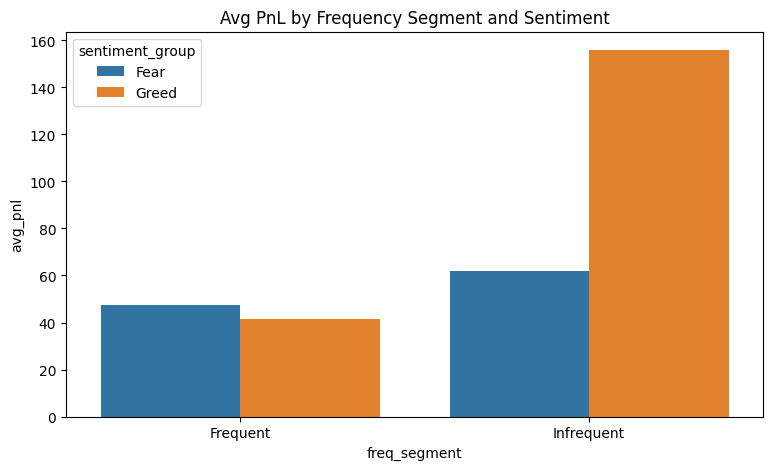

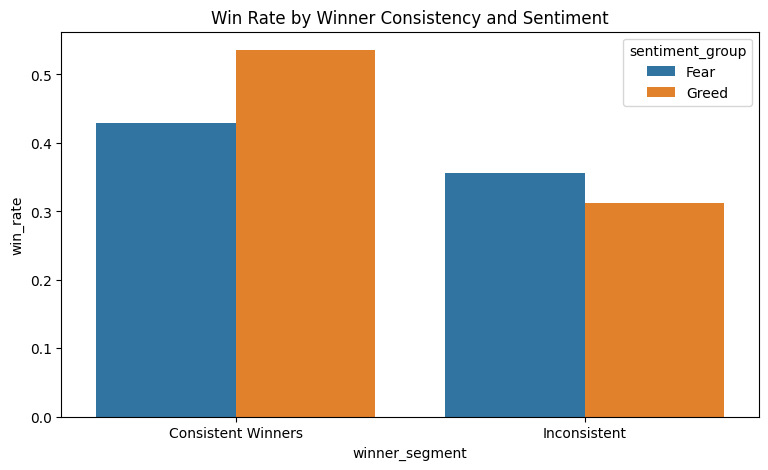

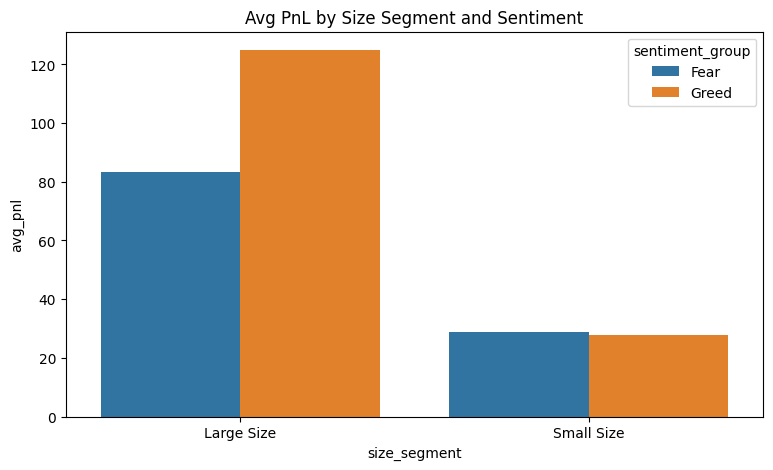

In [68]:
plt.figure(figsize=(9,5))
sns.barplot(data=freq_perf, x='freq_segment', y='avg_pnl', hue='sentiment_group')
plt.title('Avg PnL by Frequency Segment and Sentiment')
plt.show()

plt.figure(figsize=(9,5))
sns.barplot(data=winner_perf, x='winner_segment', y='win_rate', hue='sentiment_group')
plt.title('Win Rate by Winner Consistency and Sentiment')
plt.show()

plt.figure(figsize=(9,5))
sns.barplot(data=size_perf, x='size_segment', y='avg_pnl', hue='sentiment_group')
plt.title('Avg PnL by Size Segment and Sentiment')
plt.show()

In [75]:
print(freq_perf)

  freq_segment sentiment_group     avg_pnl  win_rate     avg_size  trades
0     Frequent            Fear   47.325875  0.412963  7563.359761   72515
1     Frequent           Greed   41.476621  0.424259  4643.231399   80505
2   Infrequent            Fear   61.968833  0.373438  4602.874290   10722
3   Infrequent           Greed  155.896341  0.387845  4008.612410    9790


In [76]:
print(perf_summary)

  sentiment_group  avg_daily_pnl  median_daily_pnl  total_daily_pnl  \
0            Fear    5185.146443        122.737038     4.096266e+06   
1           Greed    4144.208334        265.247725     4.865301e+06   

   avg_win_rate  avg_drawdown_proxy  median_drawdown_proxy  account_days  
0      0.357071        -8863.193211                    0.0           790  
1      0.362748        -8892.618794                    0.0          1174  


In [77]:
print(size_summary)

  sentiment_group  avg_size_usd  median_size_usd
0            Fear   7182.011019            749.4
1           Greed   4574.424490            552.2


In [78]:
print(long_short)

side         BUY  SELL
date                  
2023-05-01     3     0
2023-12-05     7     2
2023-12-14     5     6
2023-12-15     2     0
2023-12-16     3     0
...          ...   ...
2025-04-27   209   128
2025-04-28   652   727
2025-04-29  1105  1138
2025-04-30   838   275
2025-05-01   686   544

[480 rows x 2 columns]


**Part C: Optional Bonus**

**Create features and target**

In [85]:
import pandas as pd
import numpy as np

# daily_account should already exist from Part B
# expected columns:
# ['account', 'date', 'classification', 'daily_pnl', 'trades', 'avg_trade_size', 'wins', 'win_rate_day']

model_df = daily_account.copy()

# map 5 sentiment classes into 3 groups
def map_sentiment(x):
    if x in ['Extreme Fear', 'Fear']:
        return 'Fear'
    elif x in ['Greed', 'Extreme Greed']:
        return 'Greed'
    else:
        return 'Neutral'

model_df['sentiment_group'] = model_df['classification'].apply(map_sentiment)

# target: profitable day or not
model_df['target'] = (model_df['daily_pnl'] > 0).astype(int)

# build features safely
features = model_df[['win_rate_day', 'trades', 'avg_trade_size']].copy()

features['sentiment'] = model_df['sentiment_group'].map({
    'Fear': 0,
    'Neutral': 1,
    'Greed': 2
})

# final X, y
X = features.fillna(0)
y = model_df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())
print(y.head())

X shape: (2340, 4)
y shape: (2340,)
   win_rate_day  trades  avg_trade_size  sentiment
0      0.000000     177     5089.718249          2
1      0.000000      68     7976.664412          2
2      0.000000      40    23734.500000          2
3      0.000000      12    28186.666667          2
4      0.444444      27    17248.148148          2
0    0
1    0
2    0
3    0
4    1
Name: target, dtype: int64


In [86]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9423076923076923

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.88      0.92       175
           1       0.93      0.98      0.96       293

    accuracy                           0.94       468
   macro avg       0.95      0.93      0.94       468
weighted avg       0.94      0.94      0.94       468


Confusion Matrix:
 [[154  21]
 [  6 287]]


**Interpretation:**\
**Model Result**\


*   Accuracy: 94.2%
*   accuracy : very high
*   Class-wise performance: **Class 1 (Profitable days)**
Precision: 0.93\
Recall: 0.98\
F1-score: 0.96

**Model is very good at identifying profitable days**

**Class 0 (Non-profitable days)**\
Precision: 0.96\
Recall: 0.88\
F1-score: 0.92

Slightly weaker at catching losses (misses some)

**Confusion matrix interpretation**\
  

*   287 correct profitable predictions
*   154 correct loss predictions
*   21 losses predicted as profit
*   6 profits predicted as loss


  
  

**Feature Importance**


In [87]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

          feature  importance
0    win_rate_day    0.869177
1          trades    0.082686
2  avg_trade_size    0.042647
3       sentiment    0.005490


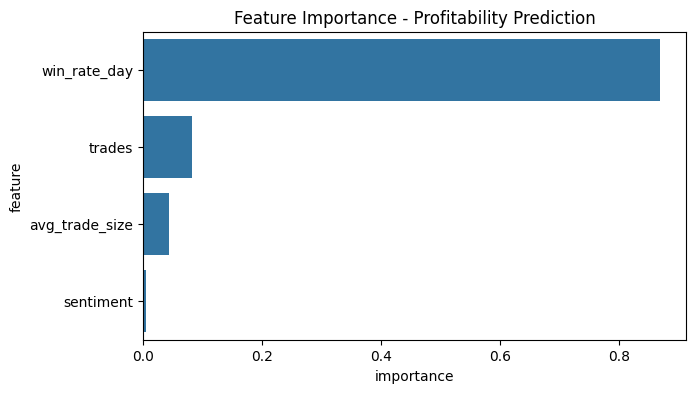

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance - Profitability Prediction')
plt.show()

As a lightweight extension, I built a Random Forest model to predict whether a trader’s daily PnL would be positive, using sentiment regime and behavioral features such as daily win rate, trade count, and average trade size.

The model achieved approx 94% accuracy, indicating strong predictive power.

Performance analysis shows:

High recall (0.98) for profitable days → the model effectively identifies profitable trading conditions.
Slightly lower recall (0.88) for loss days -> some losses are misclassified as profitable.

This suggests that trader behavior combined with market sentiment contains meaningful predictive signals for profitability.